In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
OUR_RESULT_CSV = "../../out/table/results.csv"
EDPC_RESULT_CSV = "../../out/table/EDPC_results.csv"

In [3]:
pd.options.display.float_format = "{:.3f}".format
plt.rcParams.update(
    {
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "font.size": 14,
        "axes.labelsize": 18,
        "xtick.labelsize": 18,
        "ytick.labelsize": 18,
    }
)

In [4]:
def get_number_of_instructions(circuit_name: str) -> int:
    with open(f"../../data/circuit/{circuit_name}.in") as f:
        lines = f.readlines()
    return sum(bool(line) for line in lines)

In [5]:
def load_edpc(csv_name):
    df = pd.read_csv(csv_name)
    df["factory"] = "outer"
    df["layer_count"] = 1
    df["allocator"] = "naive"
    df["msf_coeff"] = 0
    df["msf_prep_time"] = 0
    df["routing_algo"] = "EDPC"
    df["routing_option"] = "Yes_Kink"
    return df


def modify(df):
    instruction_count = {
        c: get_number_of_instructions(c) for c in df["circuit"].unique()
    }
    df["instruction_count"] = df["circuit"].map(instruction_count)
    df["cbpi"] = df["total_code_beat"] / df["instruction_count"]
    df["architecture"] = (
        df["layer_count"].map({1: "2D", 2: "2.5D"}) + " " + df["factory"]
    )
    df["allocator_msf"] = df["allocator"] + " " + df["msf_coeff"].astype(str)

    # As the Single 2D results assumes that paths take 2 code beat,
    # the cost should be doubled.
    # Also, the `yes_kink` cost should be the `no_kink` cost.
    mask = (df["routing_algo"] == "Single") & (df["layer_count"] == 1)
    metrics_cols = ["total_code_beat", "circuit_volume", "cbpi"]
    df.loc[mask, metrics_cols] *= 2

    df_single_2d = df[mask]
    df_single_2d_yes_kink = df_single_2d[
        df_single_2d["routing_option"] == "No_Kink"
    ].copy()
    df_single_2d_yes_kink["routing_option"] = "Yes_Kink"

    df = pd.concat((df, df_single_2d_yes_kink)).reset_index(drop=True)
    return df

In [6]:
def extract_best_sa(df):
    idx = df.groupby(
        [
            "circuit",
            "factory",
            "layer_count",
            "allocator",
            "routing_algo",
            "routing_option",
            "msf_prep_time",
        ]
    )["total_code_beat"].idxmin()
    return df.loc[idx]

In [7]:
order_info = {
    "architecture": ["2D outer", "2D inner", "2.5D outer", "2.5D inner"],
    "allocator": ["naive", "random", "SA"],
    "routing_algo": ["Single", "Double", "Proj."],
}

In [8]:
df_ours = modify(pd.read_csv(OUR_RESULT_CSV))
df_edpc = modify(load_edpc(EDPC_RESULT_CSV))

# Compute metrics relative to EDPC performance
df_edpc["relative_total_code_beat"] = 1.0
df_edpc["relative_circuit_volume"] = 1.0
df_edpc_sub = df_edpc[["circuit", "total_code_beat", "circuit_volume"]].rename(
    columns={
        "total_code_beat": "total_code_beat_edpc",
        "circuit_volume": "circuit_volume_edpc",
    }
)
df_merged = pd.merge(df_ours, df_edpc_sub, on="circuit", how="left")
df_merged["relative_total_code_beat"] = (
    df_merged["total_code_beat"] / df_merged["total_code_beat_edpc"]
)
df_merged["relative_circuit_volume"] = (
    df_merged["circuit_volume"] / df_merged["circuit_volume_edpc"]
)
df_ours = df_merged.drop(columns=["total_code_beat_edpc", "circuit_volume_edpc"])

df_ours_best_sa = extract_best_sa(df_ours)

# 3. Architectures

## MSF Preparation Time Comparison

### Cat Plot

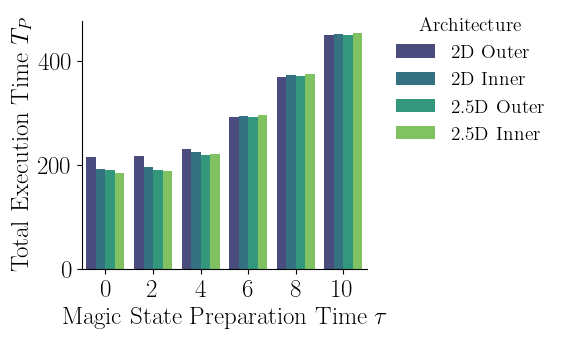

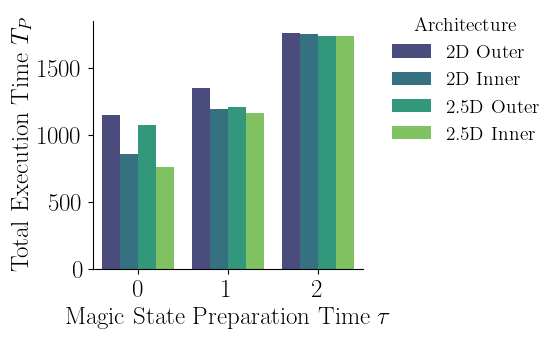

In [9]:
def change_msf_plot(df, circuit):
    df["Architecture"] = df["architecture"].map(
        {
            "2D outer": "2D Outer",
            "2D inner": "2D Inner",
            "2.5D outer": "2.5D Outer",
            "2.5D inner": "2.5D Inner",
        }
    )
    g = sns.catplot(
        data=df,
        x="msf_prep_time",
        y="total_code_beat",
        kind="bar",
        hue="Architecture",
        hue_order=["2D Outer", "2D Inner", "2.5D Outer", "2.5D Inner"],
        palette="viridis",
        height=3.5,
        aspect=1.2,
    )
    g.set_axis_labels(
        r"Magic State Preparation Time $\tau$",
        r"Total Execution Time $T_P$",
    )
    sns.move_legend(g, "upper left", bbox_to_anchor=(0.73, 1.0))
    sns.despine()
    plt.savefig(f"../../fig/{circuit}_change_msf.pdf", bbox_inches="tight")
    plt.show()


df_double = df_ours_best_sa[
    (df_ours_best_sa["routing_algo"] == "Double")
    & (df_ours_best_sa["routing_option"] == "Yes_Kink")
    & (df_ours_best_sa["allocator"] == "SA")
]
for circuit, df_circuit in sorted(df_double.groupby("circuit")):
    if "Heisenberg2D" in str(circuit) and str(circuit).endswith("6"):
        change_msf_plot(df_circuit, circuit)
    if "trotter" in str(circuit) and "det" in str(circuit):
        change_msf_plot(df_circuit, circuit)

## General Performance Trend

### Double Yes Kink SA SELECT random local 6

2D vs. 2.5D で顕著な例

,circuit,factory,layer_count,allocator,msf_coeff,msf_prep_time,routing_algo,routing_option,total_code_beat,circuit_volume,instruction_count,cbpi,architecture,allocator_msf,relative_total_code_beat,relative_circuit_volume,Factory Layout,Qubit Layout
7924,result_SELECT_100_random_local_OBC_0_0_6,inner,1,SA,0.010,2,Double,Yes_Kink,403,815772,15764,0.026,2D inner,SA 0.01,NaN,NaN,Inner Factory,2D
1014,result_SELECT_100_random_local_OBC_0_0_6,inner,2,SA,0.100,2,Double,Yes_Kink,277,567873,15764,0.018,2.5D inner,SA 0.1,NaN,NaN,Inner Factory,2.5D
7604,result_SELECT_100_random_local_OBC_0_0_6,outer,1,SA,0.001,2,Double,Yes_Kink,409,848437,15764,0.026,2D outer,SA 0.001,NaN,NaN,Outer Factory,2D
1346,result_SELECT_100_random_local_OBC_0_0_6,outer,2,SA,0.001,2,Double,Yes_Kink,289,620427,15764,0.018,2.5D outer,SA 0.001,NaN,NaN,Outer Factory,2.5D


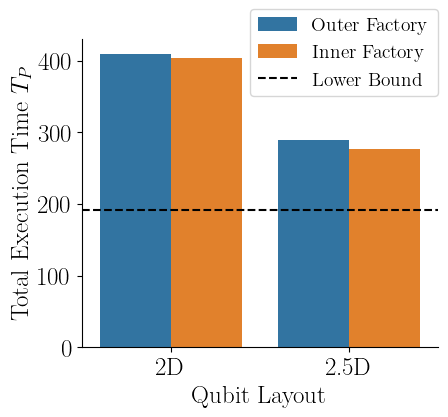

In [10]:
order_info_sa = order_info.copy()
order_info_sa["allocator"] = ["SA"]

for circuit, df_circuit in sorted(df_ours_best_sa.groupby("circuit")):
    if (
        "SELECT" in str(circuit)
        and "random" in str(circuit)
        and str(circuit).endswith("6")
    ):
        df_data = df_circuit[
            (df_circuit["allocator"] == "SA") & (df_circuit["routing_algo"] == "Double")
        ]
        df_bar = df_data[df_data["routing_option"] == "Yes_Kink"].copy()
        df_base = df_data[df_data["routing_option"] == "No_MSF"]
        df_bar["Factory Layout"] = df_bar["factory"].map(
            {"outer": "Outer Factory", "inner": "Inner Factory"}
        )
        df_bar["Qubit Layout"] = df_bar["layer_count"].map({1: "2D", 2: "2.5D"})
        display(df_bar)
        fig, ax = plt.subplots(figsize=(4.6, 4))
        g = sns.barplot(
            data=df_bar,
            x="Qubit Layout",
            y="total_code_beat",
            hue="Factory Layout",
            hue_order=["Outer Factory", "Inner Factory"],
            ax=ax,
        )
        base = df_base["total_code_beat"].iloc[0]
        plt.axhline(base, color="k", linestyle="dashed", label="Lower Bound")

        ax.set_xlabel(r"Qubit Layout")
        ax.set_ylabel(r"Total Execution Time $T_P$")

        handles, labels = ax.get_legend_handles_labels()
        ax.get_legend().remove()
        fig.legend(
            handles,
            labels,
            loc="upper right",
            bbox_to_anchor=(0.92, 0.98),
        )

        sns.despine(ax=ax)
        plt.savefig(f"../../fig/{circuit}_compare_dim.pdf", bbox_inches="tight")
        plt.show()

## evaluate_mapping.py の clone

,circuit,factory,layer_count,allocator,msf_coeff,msf_prep_time,routing_algo,routing_option,total_code_beat,circuit_volume,instruction_count,cbpi,architecture,allocator_msf,relative_total_code_beat,relative_circuit_volume
2254,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,inner,1,SA,0.001,0,Double,No_MSF,177,238336,16798,0.011,2D inner,SA 0.001,0.067,0.046
5412,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,inner,1,naive,0.000,0,Double,No_MSF,177,238336,16798,0.011,2D inner,naive 0.0,0.067,0.046
7384,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,inner,1,random,0.000,0,Double,No_MSF,177,238336,16798,0.011,2D inner,random 0.0,0.067,0.046
1442,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,outer,1,SA,0.001,0,Double,No_MSF,177,238336,16798,0.011,2D outer,SA 0.001,0.067,0.046
3502,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,outer,1,naive,0.000,0,Double,No_MSF,177,238336,16798,0.011,2D outer,naive 0.0,0.067,0.046
7643,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,outer,1,random,0.000,0,Double,No_MSF,177,238336,16798,0.011,2D outer,random 0.0,0.067,0.046


,circuit,factory,layer_count,allocator,msf_coeff,msf_prep_time,routing_algo,routing_option,total_code_beat,circuit_volume,instruction_count,cbpi,architecture,allocator_msf,relative_total_code_beat,relative_circuit_volume,Factory Layout
6458,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,inner,1,SA,0.010,0,Double,Yes_Kink,193,487447,16798,0.011,2D inner,SA 0.01,0.073,0.095,Inner Factory
5416,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,inner,1,naive,0.000,0,Double,Yes_Kink,639,1613424,16798,0.038,2D inner,naive 0.0,0.241,0.313,Inner Factory
7388,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,inner,1,random,0.000,0,Double,Yes_Kink,353,1223884,16798,0.021,2D inner,random 0.0,0.133,0.237,Inner Factory
6646,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,outer,1,SA,0.100,0,Double,Yes_Kink,217,575212,16798,0.013,2D outer,SA 0.1,0.082,0.112,Outer Factory
3506,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,outer,1,naive,0.000,0,Double,Yes_Kink,597,1532861,16798,0.036,2D outer,naive 0.0,0.225,0.297,Outer Factory
7647,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,outer,1,random,0.000,0,Double,Yes_Kink,385,1338759,16798,0.023,2D outer,random 0.0,0.145,0.260,Outer Factory


,circuit,factory,layer_count,allocator,msf_coeff,msf_prep_time,routing_algo,routing_option,total_code_beat,circuit_volume,instruction_count,cbpi,architecture,allocator_msf,relative_total_code_beat,relative_circuit_volume
2472,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,inner,2,SA,1.000,0,Double,No_MSF,177,238336,16798,0.011,2.5D inner,SA 1.0,0.067,0.046
2284,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,inner,2,naive,0.000,0,Double,No_MSF,177,238336,16798,0.011,2.5D inner,naive 0.0,0.067,0.046
7370,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,inner,2,random,0.000,0,Double,No_MSF,177,238336,16798,0.011,2.5D inner,random 0.0,0.067,0.046
3112,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,outer,2,SA,0.001,0,Double,No_MSF,177,238336,16798,0.011,2.5D outer,SA 0.001,0.067,0.046
3851,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,outer,2,naive,0.000,0,Double,No_MSF,177,238336,16798,0.011,2.5D outer,naive 0.0,0.067,0.046
7862,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,outer,2,random,0.000,0,Double,No_MSF,177,238336,16798,0.011,2.5D outer,random 0.0,0.067,0.046


,circuit,factory,layer_count,allocator,msf_coeff,msf_prep_time,routing_algo,routing_option,total_code_beat,circuit_volume,instruction_count,cbpi,architecture,allocator_msf,relative_total_code_beat,relative_circuit_volume,Factory Layout
2476,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,inner,2,SA,1.000,0,Double,Yes_Kink,186,395557,16798,0.011,2.5D inner,SA 1.0,0.070,0.077,Inner Factory
2288,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,inner,2,naive,0.000,0,Double,Yes_Kink,351,922644,16798,0.021,2.5D inner,naive 0.0,0.133,0.179,Inner Factory
7374,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,inner,2,random,0.000,0,Double,Yes_Kink,232,832776,16798,0.014,2.5D inner,random 0.0,0.088,0.162,Inner Factory
3116,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,outer,2,SA,0.001,0,Double,Yes_Kink,191,476950,16798,0.011,2.5D outer,SA 0.001,0.072,0.093,Outer Factory
3855,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,outer,2,naive,0.000,0,Double,Yes_Kink,461,1121504,16798,0.027,2.5D outer,naive 0.0,0.174,0.218,Outer Factory
7866,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,outer,2,random,0.000,0,Double,Yes_Kink,244,902024,16798,0.015,2.5D outer,random 0.0,0.092,0.175,Outer Factory


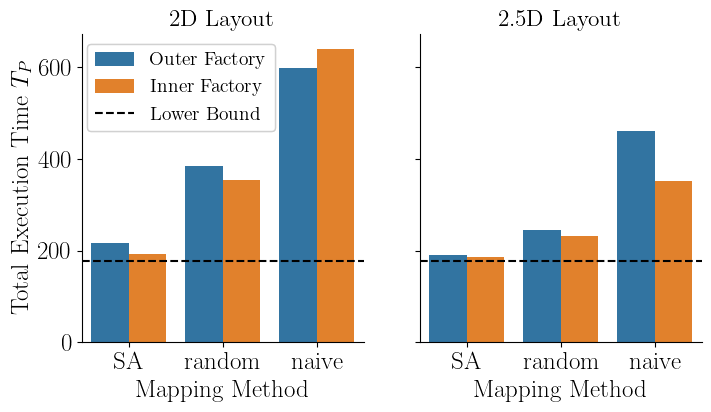

,circuit,factory,layer_count,allocator,msf_coeff,msf_prep_time,routing_algo,routing_option,total_code_beat,circuit_volume,instruction_count,cbpi,architecture,allocator_msf,relative_total_code_beat,relative_circuit_volume
2254,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,inner,1,SA,0.001,0,Double,No_MSF,177,238336,16798,0.011,2D inner,SA 0.001,0.067,0.046
5412,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,inner,1,naive,0.000,0,Double,No_MSF,177,238336,16798,0.011,2D inner,naive 0.0,0.067,0.046
7384,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,inner,1,random,0.000,0,Double,No_MSF,177,238336,16798,0.011,2D inner,random 0.0,0.067,0.046
1442,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,outer,1,SA,0.001,0,Double,No_MSF,177,238336,16798,0.011,2D outer,SA 0.001,0.067,0.046
3502,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,outer,1,naive,0.000,0,Double,No_MSF,177,238336,16798,0.011,2D outer,naive 0.0,0.067,0.046
7643,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,outer,1,random,0.000,0,Double,No_MSF,177,238336,16798,0.011,2D outer,random 0.0,0.067,0.046


,circuit,factory,layer_count,allocator,msf_coeff,msf_prep_time,routing_algo,routing_option,total_code_beat,circuit_volume,instruction_count,cbpi,architecture,allocator_msf,relative_total_code_beat,relative_circuit_volume,Factory Layout
6458,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,inner,1,SA,0.010,0,Double,Yes_Kink,193,487447,16798,0.011,2D inner,SA 0.01,0.073,0.095,Inner Factory
5416,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,inner,1,naive,0.000,0,Double,Yes_Kink,639,1613424,16798,0.038,2D inner,naive 0.0,0.241,0.313,Inner Factory
7388,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,inner,1,random,0.000,0,Double,Yes_Kink,353,1223884,16798,0.021,2D inner,random 0.0,0.133,0.237,Inner Factory
6646,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,outer,1,SA,0.100,0,Double,Yes_Kink,217,575212,16798,0.013,2D outer,SA 0.1,0.082,0.112,Outer Factory
3506,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,outer,1,naive,0.000,0,Double,Yes_Kink,597,1532861,16798,0.036,2D outer,naive 0.0,0.225,0.297,Outer Factory
7647,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,outer,1,random,0.000,0,Double,Yes_Kink,385,1338759,16798,0.023,2D outer,random 0.0,0.145,0.260,Outer Factory


,circuit,factory,layer_count,allocator,msf_coeff,msf_prep_time,routing_algo,routing_option,total_code_beat,circuit_volume,instruction_count,cbpi,architecture,allocator_msf,relative_total_code_beat,relative_circuit_volume
2472,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,inner,2,SA,1.000,0,Double,No_MSF,177,238336,16798,0.011,2.5D inner,SA 1.0,0.067,0.046
2284,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,inner,2,naive,0.000,0,Double,No_MSF,177,238336,16798,0.011,2.5D inner,naive 0.0,0.067,0.046
7370,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,inner,2,random,0.000,0,Double,No_MSF,177,238336,16798,0.011,2.5D inner,random 0.0,0.067,0.046
3112,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,outer,2,SA,0.001,0,Double,No_MSF,177,238336,16798,0.011,2.5D outer,SA 0.001,0.067,0.046
3851,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,outer,2,naive,0.000,0,Double,No_MSF,177,238336,16798,0.011,2.5D outer,naive 0.0,0.067,0.046
7862,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,outer,2,random,0.000,0,Double,No_MSF,177,238336,16798,0.011,2.5D outer,random 0.0,0.067,0.046


,circuit,factory,layer_count,allocator,msf_coeff,msf_prep_time,routing_algo,routing_option,total_code_beat,circuit_volume,instruction_count,cbpi,architecture,allocator_msf,relative_total_code_beat,relative_circuit_volume,Factory Layout
2476,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,inner,2,SA,1.000,0,Double,Yes_Kink,186,395557,16798,0.011,2.5D inner,SA 1.0,0.070,0.077,Inner Factory
2288,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,inner,2,naive,0.000,0,Double,Yes_Kink,351,922644,16798,0.021,2.5D inner,naive 0.0,0.133,0.179,Inner Factory
7374,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,inner,2,random,0.000,0,Double,Yes_Kink,232,832776,16798,0.014,2.5D inner,random 0.0,0.088,0.162,Inner Factory
3116,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,outer,2,SA,0.001,0,Double,Yes_Kink,191,476950,16798,0.011,2.5D outer,SA 0.001,0.072,0.093,Outer Factory
3855,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,outer,2,naive,0.000,0,Double,Yes_Kink,461,1121504,16798,0.027,2.5D outer,naive 0.0,0.174,0.218,Outer Factory
7866,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_6,outer,2,random,0.000,0,Double,Yes_Kink,244,902024,16798,0.015,2.5D outer,random 0.0,0.092,0.175,Outer Factory


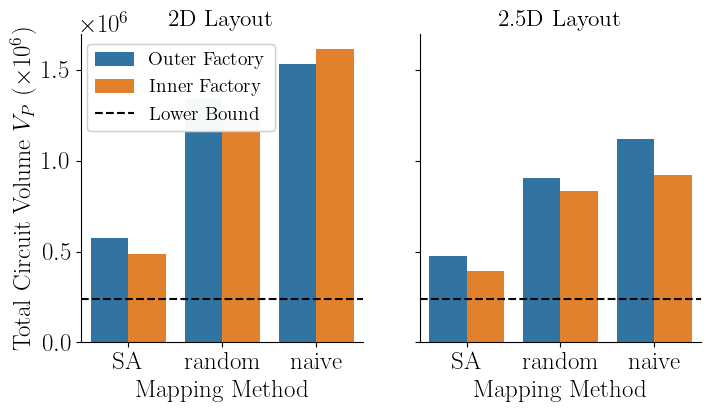

In [ ]:
# We used SELECT 6 since the methods reach near-optimal for SELECT 5.

order_info_sa = order_info.copy()
order_info_sa["allocator"] = ["SA"]

allocation_order = ["SA", "random", "naive"]

for metric, metric_label in [
    ("total_code_beat", r"Total Execution Time $T_P$"),
    ("circuit_volume", r"Total Circuit Volume $V_P$ ($\times10^6$)"),
]:
    for circuit, df_circuit in sorted(df_ours_best_sa.groupby("circuit")):
        if (
            "SELECT" in str(circuit)
            # and "Heisenberg2D" in str(circuit)
            and str(circuit).endswith("6")
        ):
            fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)
            sns.despine(fig)
            for layer_count, ax in enumerate(axes, start=1):
                df_data = df_circuit[
                    (df_circuit["layer_count"] == layer_count)
                    & (df_circuit["routing_algo"] == "Double")
                    & (df_circuit["msf_prep_time"] == 0)
                ]
                df_bar = df_data[df_data["routing_option"] == "Yes_Kink"].copy()
                df_base = df_data[df_data["routing_option"] == "No_MSF"]
                df_bar["Factory Layout"] = df_bar["factory"].map(
                    {"outer": "Outer Factory", "inner": "Inner Factory"}
                )

                display(df_base)
                display(df_bar)
                g = sns.barplot(
                    data=df_bar,
                    x="allocator",
                    y=metric,
                    order=allocation_order,
                    hue="Factory Layout",
                    hue_order=["Outer Factory", "Inner Factory"],
                    ax=ax,
                )
                base = df_base[metric].iloc[0]
                ax.axhline(base, color="k", linestyle="dashed", label="Lower Bound")

                dim = "2D" if layer_count == 1 else "2.5D"
                title = f"{dim} Layout"
                ax.set_title(title, fontweight="bold")
                ax.set_xlabel("Mapping Method", fontweight="bold")
                ax.set_ylabel(metric_label, fontweight="bold")

                handles, labels = ax.get_legend_handles_labels()
                ax.get_legend().remove()
                fig.legend(
                    handles,
                    labels,
                    loc="upper left",
                    bbox_to_anchor=(0.12, 0.88),
                )

            plt.savefig(
                f"../../fig/{circuit}_{metric}_compare_inner_outer.pdf",
                bbox_inches="tight",
            )
            plt.show()

## Routing Comparison

### Routing + Mapping でプロット

In [12]:
# option_styles = {
#     "No_MSF": {"label": "Sync", "color": "C1"},
#     "No_Top": {"label": "Magic", "color": "C2"},
#     "No_Kink": {"label": "Path", "color": "C3"},
#     "Yes_Kink": {"label": "Kink", "color": "C4"},
# }

# delim = r" / "

# routing_allocators = [
#     f"EDPC{delim}naive",
#     f"Single{delim}naive",
#     f"Double{delim}naive",
#     f"Proj.{delim}naive",
#     f"Single{delim}SA",
#     f"Double{delim}SA",
#     f"Proj.{delim}SA",
# ]

# df_merged = pd.concat((df_ours_best_sa, df_edpc))
# df_merged[f"Routing{delim}Mapping"] = (
#     df_merged["routing_algo"].map(lambda f: (f + "." if f == "Proj" else f))
#     + delim
#     + df_merged["allocator"]
# )

# df_arc = df_merged[
#     (df_merged["factory"] == "outer")
#     & (df_merged["layer_count"] == 1)
#     & (df_merged["msf_prep_time"] == 2)
# ].copy()
# df_arc["circuit_volume_scaled"] = df_arc["circuit_volume"] / 1e6

# for circuit, df_circuit in sorted(df_arc.groupby("circuit")):
#     if "SELECT" in str(circuit) and str(circuit).endswith("6"):
#         fig, axes = plt.subplots(1, 2, figsize=(10, 3))
#         for ax, metric, xlabel in zip(
#             axes,
#             ["cbpi", "circuit_volume_scaled"],
#             ["CBPI", r"Total Circuit Volume ($\times10^6$)"],
#         ):
#             stack_height = []
#             for routing_option, style in reversed(option_styles.items()):
#                 sns.barplot(
#                     data=df_circuit[df_circuit["routing_option"] == routing_option],
#                     x=metric,
#                     y=f"Routing{delim}Mapping",
#                     ax=ax,
#                     order=routing_allocators,
#                     **style,
#                 )
#             base = df_circuit[
#                 (df_circuit["routing_algo"] == "Proj.")
#                 & (df_circuit["routing_option"] == "No_MSF")
#             ][metric].iloc[0]

#             df_base = pd.DataFrame(
#                 {
#                     f"Routing{delim}Mapping": routing_allocators,
#                     metric: [base] * len(routing_allocators),
#                 }
#             )
#             print(df_base)
#             sns.barplot(
#                 data=df_base,
#                 x=metric,
#                 y=f"Routing{delim}Mapping",
#                 ax=ax,
#                 order=routing_allocators,
#                 color="C0",
#                 label="Base",
#             )
#             sns.barplot(
#                 data=df_circuit,
#                 x=metric,
#                 y=f"Routing{delim}Mapping",
#                 ax=ax,
#                 order=[routing_allocators[0]],
#                 color="gray",
#             )
#             ax.set_xlabel(xlabel)
#             sns.despine(ax=ax)
#         # plt.savefig(f"../../fig/{circuit}_compare_dim.pdf", bbox_inches="tight")

#         axes[0].get_legend().remove()
#         handles, labels = axes[1].get_legend_handles_labels()
#         axes[1].get_legend().remove()
#         fig.legend(
#             handles,
#             labels,
#             loc="upper left",
#             bbox_to_anchor=(1, 0.75),
#         )

#         plt.tight_layout()
#         plt.savefig("../../fig/compare_routing_and_allocator.pdf", bbox_inches="tight")
#         plt.show()

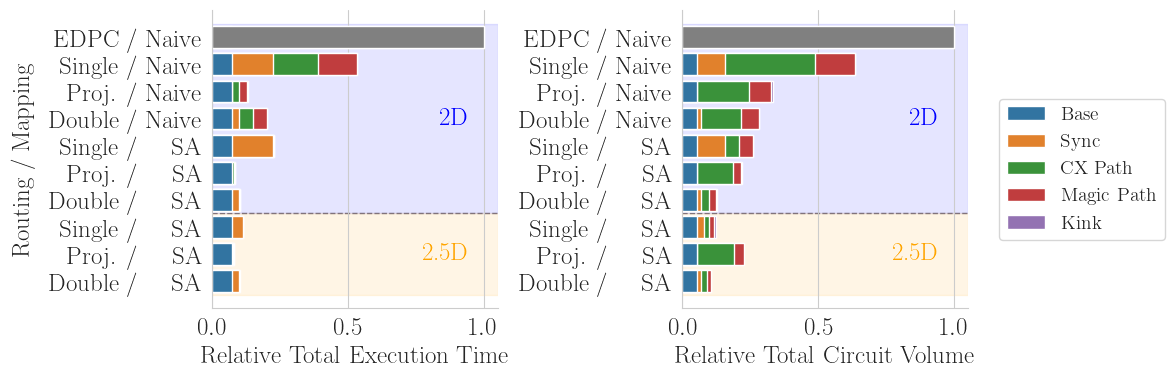

In [13]:
# 2.5D も追加した version

option_styles = {
    "No_MSF": {"label": "Sync", "color": "C1"},
    "No_MP": {"label": "CX Path", "color": "C2"},
    "No_Kink": {"label": "Magic Path", "color": "C3"},
    "Yes_Kink": {"label": "Kink", "color": "C4"},
}

delim = r" / "

layer_count_repr_dict = {1: "2D", 2: "2.5D"}

x_column_name = f"Routing{delim}Mapping{delim}Dimension"

routing_allocator_dimensions = [
    f"EDPC{delim}naive{delim}2D",
    f"Single{delim}naive{delim}2D",
    f"Proj.{delim}naive{delim}2D",
    f"Double{delim}naive{delim}2D",
    f"Single{delim}SA{delim}2D",
    f"Proj.{delim}SA{delim}2D",
    f"Double{delim}SA{delim}2D",
    f"Single{delim}SA{delim}2.5D",
    f"Proj.{delim}SA{delim}2.5D",
    f"Double{delim}SA{delim}2.5D",
]

df_merged = pd.concat((df_ours_best_sa, df_edpc))

df_merged[x_column_name] = (
    df_merged["routing_algo"]
    + delim
    + df_merged["allocator"]
    + delim
    + df_merged["layer_count"].map(layer_count_repr_dict)
)

df_arc = df_merged[
    (df_merged["factory"] == "outer") & (df_merged["msf_prep_time"] == 0)
].copy()

df_arc["circuit_volume_scaled"] = df_arc["circuit_volume"] / 1e6

for circuit, df_circuit in sorted(df_arc.groupby("circuit")):
    if "SELECT" in str(circuit) and str(circuit).endswith("5"):
        sns.set_style(
            "whitegrid",
            rc={
                "text.usetex": True,
                "font.family": "serif",
                "font.serif": ["Computer Modern Roman"],
                "font.size": 14,
            },
        )
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        for ax, metric, xlabel in zip(
            axes,
            ["relative_total_code_beat", "relative_circuit_volume"],
            [
                r"Relative Total Execution Time",
                r"Relative Total Circuit Volume",
            ],
        ):
            stack_height = []
            for routing_option, style in reversed(option_styles.items()):
                sns.barplot(
                    data=df_circuit[df_circuit["routing_option"] == routing_option],
                    x=metric,
                    y=x_column_name,
                    ax=ax,
                    order=routing_allocator_dimensions,
                    **style,
                )
            base = df_circuit[
                (df_circuit["routing_algo"] == "Proj.")
                & (df_circuit["routing_option"] == "No_MSF")
            ][metric].iloc[0]

            df_base = pd.DataFrame(
                {
                    x_column_name: routing_allocator_dimensions,
                    metric: [base] * len(routing_allocator_dimensions),
                }
            )
            sns.barplot(
                data=df_base,
                x=metric,
                y=x_column_name,
                ax=ax,
                order=routing_allocator_dimensions,
                color="C0",
                label="Base",
            )
            sns.barplot(
                data=df_circuit,
                x=metric,
                y=x_column_name,
                ax=ax,
                order=[routing_allocator_dimensions[0]],
                color="gray",
            )

            # y軸のラベルを短いものに置き換え（FixedLocatorで警告回避）
            def get_label(s):
                routing, allocator, _ = s.split(delim)
                if allocator == "naive":
                    allocator = "Naive"
                return (
                    f"{routing}{delim}" + r"\hphantom{Naive}\llap{" + allocator + r"}"
                )

            ax.set_yticks(range(len(routing_allocator_dimensions)))
            ax.set_yticklabels(list(map(get_label, routing_allocator_dimensions)))
            ax.set_xlabel(xlabel)

            # 背景に2Dと2.5Dの注釈を追加
            xlim = ax.get_xlim()
            ylim = ax.get_ylim()
            y_line = 6.5
            ax.axhline(y=y_line, color="gray", linestyle="--", linewidth=1, zorder=0)
            ax.axhspan(-0.5, y_line, alpha=0.1, color="blue", zorder=0)
            ax.axhspan(y_line, 9.5, alpha=0.1, color="orange", zorder=0)

            # 2Dのテキスト
            for y, text_content, color in [(3, "2D", "blue"), (8, "2.5D", "orange")]:
                ax.text(
                    xlim[1] * 0.9,
                    y,
                    text_content,
                    ha="right",
                    va="center",
                    fontsize=18,
                    weight="bold",
                    color=color,
                )

            sns.despine(ax=ax)
        # plt.savefig(f"../../fig/{circuit}_compare_dim.pdf", bbox_inches="tight")

        axes[0].set_ylabel(f"Routing{delim}Mapping", fontsize=18, labelpad=10)
        axes[1].set_ylabel("")

        axes[0].get_legend().remove()
        handles, labels = axes[1].get_legend_handles_labels()
        axes[1].get_legend().remove()
        fig.legend(
            handles[::-1],
            labels[::-1],
            loc="upper left",
            bbox_to_anchor=(1, 0.75),
        )

        plt.tight_layout()
        plt.savefig(
            "../../fig/compare_routing_and_allocator_and_dimension.pdf",
            bbox_inches="tight",
        )
        plt.show()

In [14]:
for parallel in (4, 5, 6):
    df_heisenberg_2d = df_arc[
        (
            df_arc["circuit"]
            == f"result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_{parallel}"
        )
        & (df_arc["routing_option"] == "Yes_Kink")
        & (df_arc["architecture"] == "2D outer")
    ]

    ratios = [
        ("Single / naive / 2D", "Single / SA / 2D"),
        ("Single / SA / 2D", "Double / SA / 2D"),
        ("Single / naive / 2D", "Double / SA / 2D"),
        ("Proj. / SA / 2D", "Double / SA / 2D"),
        # ("Double / SA / 2D", "Proj. / SA / 2D"),
    ]

    def get_by_rmd(label):
        return df_heisenberg_2d[
            df_heisenberg_2d["Routing / Mapping / Dimension"] == label
        ].iloc[0]

    print(f"SELECT {parallel}")
    for metric in ("total_code_beat", "circuit_volume_scaled"):
        print(metric)
        for before_rmd, after_rmd in ratios:
            before = get_by_rmd(before_rmd)
            after = get_by_rmd(after_rmd)
            ratio = after[metric]
            print(
                before_rmd,
                "divided by",
                after_rmd,
                f"{ratio:.1f}",
                ratio,
            )
    print()

SELECT 4
total_code_beat
Single / naive / 2D divided by Single / SA / 2D 1142.0 1142
Single / SA / 2D divided by Double / SA / 2D 523.0 523
Single / naive / 2D divided by Double / SA / 2D 523.0 523
Proj. / SA / 2D divided by Double / SA / 2D 523.0 523
circuit_volume_scaled
Single / naive / 2D divided by Single / SA / 2D 0.7 0.657324
Single / SA / 2D divided by Double / SA / 2D 0.3 0.321823
Single / naive / 2D divided by Double / SA / 2D 0.3 0.321823
Proj. / SA / 2D divided by Double / SA / 2D 0.3 0.321823

SELECT 5
total_code_beat
Single / naive / 2D divided by Single / SA / 2D 662.0 662
Single / SA / 2D divided by Double / SA / 2D 301.0 301
Single / naive / 2D divided by Double / SA / 2D 301.0 301
Proj. / SA / 2D divided by Double / SA / 2D 301.0 301
circuit_volume_scaled
Single / naive / 2D divided by Single / SA / 2D 0.8 0.807504
Single / SA / 2D divided by Double / SA / 2D 0.4 0.395147
Single / naive / 2D divided by Double / SA / 2D 0.4 0.395147
Proj. / SA / 2D divided by Double / 

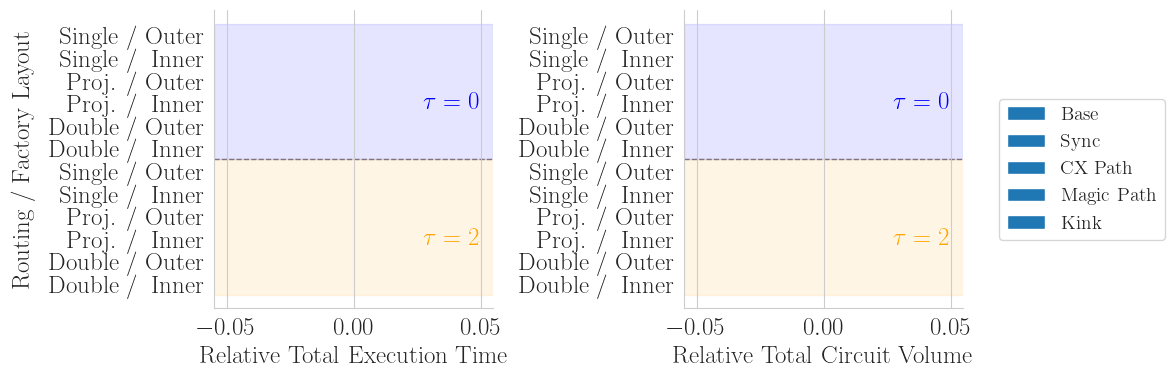

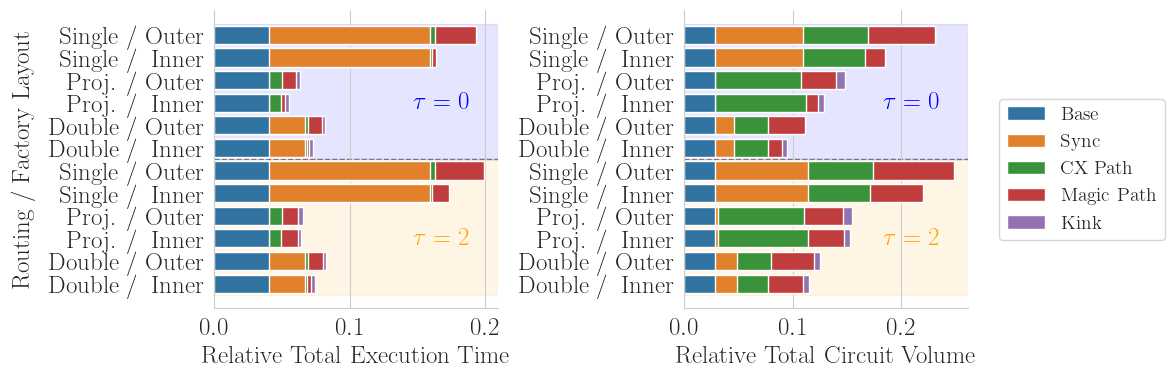

In [15]:
# 2.5D も追加した version

option_styles = {
    "No_MSF": {"label": "Sync", "color": "C1"},
    "No_MP": {"label": "CX Path", "color": "C2"},
    "No_Kink": {"label": "Magic Path", "color": "C3"},
    "Yes_Kink": {"label": "Kink", "color": "C4"},
}

delim = r" / "

layer_count_repr_dict = {1: "2D", 2: "2.5D"}

x_column_name = f"Routing{delim}Mapping{delim}Layout{delim}Prep"

routing_allocator_dimensions = [
    # f"EDPC{delim}naive{delim}outer{delim}0",
    f"Single{delim}SA{delim}outer{delim}0",
    f"Single{delim}SA{delim}inner{delim}0",
    f"Proj.{delim}SA{delim}outer{delim}0",
    f"Proj.{delim}SA{delim}inner{delim}0",
    f"Double{delim}SA{delim}outer{delim}0",
    f"Double{delim}SA{delim}inner{delim}0",
    f"Single{delim}SA{delim}outer{delim}2",
    f"Single{delim}SA{delim}inner{delim}2",
    f"Proj.{delim}SA{delim}outer{delim}2",
    f"Proj.{delim}SA{delim}inner{delim}2",
    f"Double{delim}SA{delim}outer{delim}2",
    f"Double{delim}SA{delim}inner{delim}2",
]

df_merged = pd.concat((df_ours_best_sa, df_edpc))

df_merged[x_column_name] = (
    df_merged["routing_algo"]
    + delim
    + df_merged["allocator"]
    + delim
    + df_merged["factory"]
    + delim
    + df_merged["msf_prep_time"].astype(str)
)

df_arc = df_merged[
    # (df_merged["factory"] == "outer") &
    ((df_merged["allocator"] == "SA") | (df_merged["routing_algo"] == "EDPC"))
    & (df_merged["layer_count"] == 1)
    # & (df_merged["msf_prep_time"] == 0)
].copy()
df_arc["circuit_volume_scaled"] = df_arc["circuit_volume"] / 1e6

for circuit, df_circuit in sorted(df_arc.groupby("circuit")):
    if "SELECT" in str(circuit) and str(circuit).endswith("6"):
        sns.set_style(
            "whitegrid",
            rc={
                "text.usetex": True,
                "font.family": "serif",
                "font.serif": ["Computer Modern Roman"],
                "font.size": 14,
            },
        )
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        for ax, metric, xlabel in zip(
            axes,
            ["relative_total_code_beat", "relative_circuit_volume"],
            [
                r"Relative Total Execution Time",
                r"Relative Total Circuit Volume",
            ],
        ):
            stack_height = []
            for routing_option, style in reversed(option_styles.items()):
                sns.barplot(
                    data=df_circuit[df_circuit["routing_option"] == routing_option],
                    x=metric,
                    y=x_column_name,
                    ax=ax,
                    order=routing_allocator_dimensions,
                    **style,
                )
            base = df_circuit[
                (df_circuit["routing_algo"] == "Proj.")
                & (df_circuit["routing_option"] == "No_MSF")
            ][metric].iloc[0]

            df_base = pd.DataFrame(
                {
                    x_column_name: routing_allocator_dimensions,
                    metric: [base] * len(routing_allocator_dimensions),
                }
            )
            sns.barplot(
                data=df_base,
                x=metric,
                y=x_column_name,
                ax=ax,
                order=routing_allocator_dimensions,
                color="C0",
                label="Base",
            )
            # sns.barplot(
            #     data=df_circuit,
            #     x=metric,
            #     y=x_column_name,
            #     ax=ax,
            #     order=[routing_allocator_dimensions[0]],
            #     color="gray",
            # )

            # y軸のラベルを短いものに置き換え（FixedLocatorで警告回避）
            def get_label(s):
                routing, _, factory_layout, _ = s.split(delim)
                return (
                    f"{routing}{delim}"
                    + r"\hphantom{Outer}\llap{"
                    + factory_layout.capitalize()
                    + r"}"
                )

            ax.set_yticks(range(len(routing_allocator_dimensions)))
            ax.set_yticklabels(
                list(
                    map(
                        get_label,
                        routing_allocator_dimensions,
                    )
                )
            )
            ax.set_xlabel(xlabel)

            # 背景に2Dと2.5Dの注釈を追加
            xlim = ax.get_xlim()
            ylim = ax.get_ylim()
            y_line = 5.5
            ax.axhline(y=y_line, color="gray", linestyle="--", linewidth=1, zorder=0)
            ax.axhspan(-0.5, y_line, alpha=0.1, color="blue", zorder=0)
            ax.axhspan(y_line, 11.5, alpha=0.1, color="orange", zorder=0)

            # 2Dのテキスト
            for y, text_content, color in [
                (3, r"$\tau = 0$", "blue"),
                (9, r"$\tau = 2$", "orange"),
            ]:
                ax.text(
                    xlim[1] * 0.9,
                    y,
                    text_content,
                    ha="right",
                    va="center",
                    fontsize=18,
                    weight="bold",
                    color=color,
                )

            sns.despine(ax=ax)
        # plt.savefig(f"../../fig/{circuit}_compare_dim.pdf", bbox_inches="tight")

        axes[0].set_ylabel(f"Routing{delim}Factory Layout", fontsize=18, labelpad=10)
        axes[1].set_ylabel("")

        axes[0].get_legend().remove()
        handles, labels = axes[1].get_legend_handles_labels()
        axes[1].get_legend().remove()
        fig.legend(
            handles[::-1],
            labels[::-1],
            loc="upper left",
            bbox_to_anchor=(1, 0.75),
        )

        plt.tight_layout()
        plt.savefig(
            "../../fig/magic_breakdown.pdf",
            bbox_inches="tight",
        )
        plt.show()

## CV-CB Plot

In [16]:
# import matplotlib.patches as patches
from matplotlib.lines import Line2D

factory = "outer"
layer_count = 1

SELECT_REPEAT = 36652
TROTTER_REPEAT = 161636

ENLARGED_MAX_X = 0.5
ENLARGED_MAX_Y = 5

OVERALL_MAX_X = 6.2
OVERALL_MAX_Y = 20

df_all = modify(pd.read_csv(OUR_RESULT_CSV))
df_all = extract_best_sa(df_all)
df_circuit = df_all[
    df_all["circuit"].str.match("result_.*_10_Heisenberg2D_.*", na=False)
]
df_edpc = modify(load_edpc(EDPC_RESULT_CSV))

df_arc = df_circuit[
    (df_circuit["routing_option"] == "Yes_Kink")
    & (df_circuit["allocator"] == "SA")
    & (
        ((df_circuit["factory"] == "outer") & (df_circuit["msf_prep_time"] == 0))
        | (df_circuit["factory"] == "inner") & (df_circuit["msf_prep_time"] == 2)
    )
    & (df_circuit["layer_count"] == layer_count)
].copy()

df_edpc["routing_algo"] = "EDPC"
df_merged = pd.concat((df_edpc, df_arc))
df_merged["total_code_beat_scaled"] = df_merged["total_code_beat"]
df_merged["circuit_volume_scaled"] = df_merged["circuit_volume"]

display(df_merged)

# for routing_algo in ("Double", "Proj"):
# df_ra = df_arc[df_arc["routing_algo"] == routing_algo]
splitted_circuit_series = df_merged["circuit"].str.split("_")
df_merged["circuit_type"] = splitted_circuit_series.map(
    lambda l: "SELECT" if l[1] == "SELECT" else f"Trotter ({l[-1]}.)"
)
df_merged["circuit_suffix"] = splitted_circuit_series.map(lambda l: l[-1])
df_merged["factory_tau"] = (
    df_merged["factory"] + delim + df_merged["msf_prep_time"].astype(str)
)
# display(df_arc)

df_select = df_merged[(df_merged["circuit_type"] == "SELECT")].copy()
df_select["parallel"] = df_select["circuit_suffix"].astype(int)
df_select.sort_values("parallel")
df_select["total_code_beat_scaled"] *= SELECT_REPEAT
df_select["circuit_volume_scaled"] *= SELECT_REPEAT

df_trotter = df_merged[(df_merged["circuit_type"] != "SELECT")].copy()
df_trotter["total_code_beat_scaled"] *= TROTTER_REPEAT
df_trotter["circuit_volume_scaled"] *= TROTTER_REPEAT

# display(df_trotter)

,circuit,total_code_beat,circuit_volume,factory,layer_count,allocator,msf_coeff,msf_prep_time,routing_algo,routing_option,instruction_count,cbpi,architecture,allocator_msf,total_code_beat_scaled,circuit_volume_scaled
0,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_1,10453,1729600,outer,1,naive,0.000,0,EDPC,Yes_Kink,12314,0.849,2D outer,naive 0,10453,1729600
1,result_trotter_10_Heisenberg2D_cylinder_0.5_0....,3339,652754,outer,1,naive,0.000,0,EDPC,Yes_Kink,27720,0.120,2D outer,naive 0,3339,652754
2,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_0,14695,1973490,outer,1,naive,0.000,0,EDPC,Yes_Kink,12242,1.200,2D outer,naive 0,14695,1973490
3,result_trotter_10_Heisenberg2D_cylinder_0.5_0....,2672,544680,outer,1,naive,0.000,0,EDPC,Yes_Kink,27720,0.096,2D outer,naive 0,2672,544680
4,result_SELECT_10_Heisenberg2D_cylinder_0.5_0.5_2,8202,1966008,outer,1,naive,0.000,0,EDPC,Yes_Kink,12482,0.657,2D outer,naive 0,8202,1966008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
815,result_trotter_10_Heisenberg2D_cylinder_0.5_0....,2042,856470,inner,1,SA,0.010,2,Proj.,Yes_Kink,27720,0.074,2D inner,SA 0.01,2042,856470
8990,result_trotter_10_Heisenberg2D_cylinder_0.5_0....,3492,856828,inner,1,SA,1.000,2,Single,Yes_Kink,27720,0.126,2D inner,SA 1.0,3492,856828
5024,result_trotter_10_Heisenberg2D_cylinder_0.5_0....,1133,367511,outer,1,SA,0.100,0,Double,Yes_Kink,27720,0.041,2D outer,SA 0.1,1133,367511
5785,result_trotter_10_Heisenberg2D_cylinder_0.5_0....,994,387366,outer,1,SA,1.000,0,Proj.,Yes_Kink,27720,0.036,2D outer,SA 1.0,994,387366


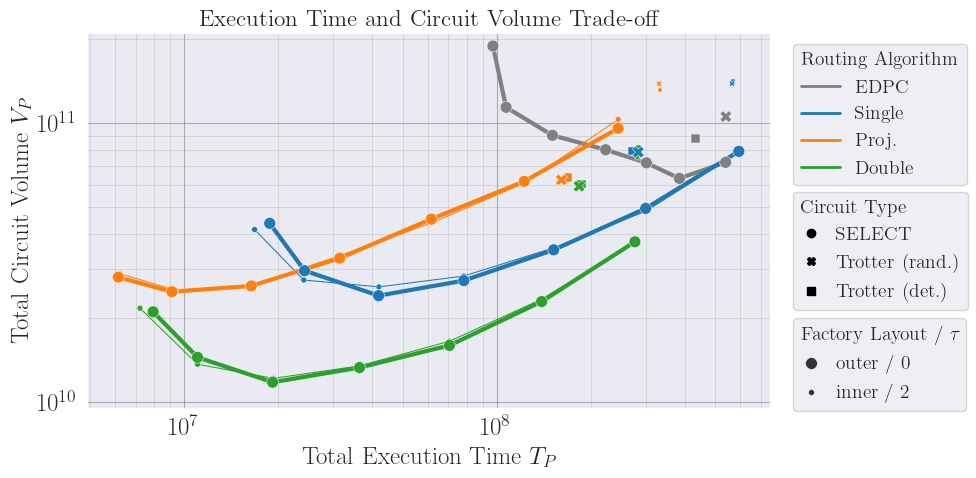

In [17]:
import numpy as np
from matplotlib.ticker import LogLocator

palette = {
    "EDPC": "gray",
    "Single": "C0",
    "Proj.": "C1",
    "Double": "C2",
}


size_order = [
    f"outer{delim}0",
    f"inner{delim}2",
]

sns.set_style(
    "darkgrid",
    rc={
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "font.size": 14,
    },
)
fig, ax = plt.subplots(figsize=(10, 5))

sns.lineplot(
    df_select,
    x="total_code_beat_scaled",
    y="circuit_volume_scaled",
    hue="routing_algo",
    hue_order=["EDPC", "Single", "Proj.", "Double"],
    size="factory_tau",
    size_order=size_order,
    legend=False,
    zorder=1,
    ax=ax,
    palette=palette,
)

sns.scatterplot(
    pd.concat((df_select, df_trotter)),
    x="total_code_beat_scaled",
    y="circuit_volume_scaled",
    hue="routing_algo",
    style="circuit_type",
    hue_order=["EDPC", "Single", "Proj.", "Double"],
    size="factory_tau",
    size_order=size_order,
    legend=True,
    markers=True,
    zorder=2,
    ax=ax,
    palette=palette,
)

dim = "2D" if layer_count == 1 else "2.5D"
ax.set_title("Execution Time and Circuit Volume Trade-off")
ax.set_xlabel("Total Execution Time $T_P$")
ax.set_ylabel("Total Circuit Volume $V_P$")
ax.set_xscale("log")
ax.set_yscale("log")

ax.xaxis.set_major_locator(LogLocator(base=10))
ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
ax.yaxis.set_major_locator(LogLocator(base=10))
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))

ax.grid(True, which="major", alpha=0.6, linestyle="-", linewidth=0.8, color="gray")
ax.grid(True, which="minor", alpha=0.3, linestyle="-", linewidth=0.5, color="gray")

# ここにおかないと、いくつかの設定が上書きされる
sns.despine(ax=ax, left=False, bottom=False)

y_data = pd.concat((df_select, df_trotter))["circuit_volume_scaled"]
y_min = y_data.min()
y_max = y_data.max()
ax.set_ylim(0.95 * 10 ** (np.floor(np.log10(y_min))), y_max * 1.1)

handles, labels = ax.get_legend_handles_labels()

legend1 = ax.legend(
    handles=[
        Line2D([], [], color=palette[name], lw=2, label=name) for name in palette.keys()
    ],
    title="Routing Algorithm",
    loc="upper left",
    alignment="left",
    bbox_to_anchor=(1.02, 1.0),
)

ax.add_artist(legend1)

# https://seaborn.pydata.org/tutorial/properties.html
marker_names = labels[labels.index("circuit_type") + 1 :]
marker_makers = ["o", "X", "s", "P", "D"][: len(marker_names)]

legend2 = ax.legend(
    handles=[
        Line2D([], [], linestyle="", marker=marker, color="black", label=name)
        for name, marker in zip(marker_names, marker_makers)
    ],
    title="Circuit Type",
    loc="upper left",
    alignment="left",
    handlelength=1.0,
    bbox_to_anchor=(1.02, 0.605),
)

ax.add_artist(legend2)

# factory / tau
factory_tau_count = 2
all_handles, all_labels = ax.get_legend_handles_labels()
size_start_idx = all_labels.index("factory_tau") + 1
size_handles = all_handles[size_start_idx : size_start_idx + factory_tau_count]
size_labels = all_labels[size_start_idx : size_start_idx + factory_tau_count]

ax.legend(
    handles=size_handles,
    labels=size_labels,
    title=r"Factory Layout / $\tau$",
    loc="upper left",
    alignment="left",
    handlelength=1.0,
    bbox_to_anchor=(1.02, 0.268),
)

plt.tight_layout()
plt.savefig("../../fig/cb_cv_plot.pdf")
plt.show()